# Stack Experiment

In [37]:
from helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *
%reload_ext autoreload
%autoreload 2
import helpers, helpersGeneration, helpersTracking, helpersStatistics, helpersAssignment

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
D = [0,1,2,3,4]
F = [10, 1000] # 10 or 1000 frames
N = 10

## 1. Single D demo  
10 frames, 10 particles, D=1

In [ ]:
frames, trajectories_GT, D_GT = generate_frames_setD(F[0], N, D[1])

Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9


In [ ]:
view_frames(frames)

### 1.0 $ D_{GT} $

In [5]:
print(D_GT)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### 1.1 $ D_{trajectory} $

In [6]:
MAE_trajectory = compute_MAE_trajectory(trajectories_GT, D_GT)

D_trajectory: 
[0.177, 0.180, 0.076, 0.263, 0.854, 0.448, 0.137, 0.382, 0.397, 0.749]
MAE for D_trajectory: 
[0.823, 0.820, 0.924, 0.737, 0.146, 0.552, 0.863, 0.618, 0.603, 0.251]


### 1.2 $ D_{detection} $

In [7]:
detected_peaks = detect_peaks(frames)

In [8]:
trajectories_detection = NN_tracking(detected_peaks, max_distance=5)

In [ ]:
trajectories_detection, min_cost_detection, assignment_detection = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian')

Assignment:
 [4 3 9 7 0 1 8]


In [10]:
MAE_detection = compute_MAE_detection(trajectories_detection, D_GT)

D_detection:
['0.500', '0.264', 'nan', '0.149', 'nan', 'nan', 'nan', '0.500', '0.575', '0.250']
MAE for D_detection:
['0.500', '0.736', 'nan', '0.851', 'nan', 'nan', 'nan', '0.500', '0.425', '0.750']


### 1.3 $ D_{localization} $

In [11]:
localized_peaks = localize_peaks_with_gaussian_fitting(frames, detected_peaks)

In [12]:
trajectories_localization = NN_tracking(localized_peaks, max_distance=5)

In [ ]:
trajectories_localization, min_cost_localization, assignment_localization = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='hungarian')

Assignment:
 [4 3 9 7 0 1 8]


In [14]:
MAE_localization = compute_MAE_localization(trajectories_localization, D_GT)

D_localization:
['0.326', '0.240', 'nan', '0.136', 'nan', 'nan', 'nan', '0.250', '0.383', '0.250']
MAE for D_localization:
['0.674', '0.760', 'nan', '0.864', 'nan', 'nan', 'nan', '0.750', '0.617', '0.750']


## 2. Full demo - 10 frames

In [15]:
MAE_t_array_10 = []
MAE_d_array_10 = []
MAE_l_array_10 = []

for d in D:
    MAE_t, MAE_d, MAE_l = compute_MAEs_setD(F[0], N, d)

    MAE_t_array_10.append(MAE_t)
    MAE_d_array_10.append(MAE_d)
    MAE_l_array_10.append(MAE_l)

# convert to 2D numpy arrays for plotting
MAE_t_array = np.array(MAE_t_array_10)
MAE_d_array = np.array(MAE_d_array_10)
MAE_l_array = np.array(MAE_l_array_10)

Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[-0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000]
MAE for D_trajectory: 
[0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000]
Assignment:
 [8 3 5 2 0 9 6]
D_detection:
['-0.000', 'nan', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', 'nan', '-0.000', '-0.000']
MAE for D_detection:
['0.000', 'nan', '0.000', '0.000', 'nan', '0.000', '0.000', 'nan', '0.000', '0.000']
Assignment:
 [8 3 5 2 0 9 6]
D_localization:
['-0.000', 'nan', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', 'nan', '-0.000', '-0.000']
MAE for D_localization:
['0.000', 'nan', '0.000', '0.000', 'nan', '0.000', '0.000', 'nan', '0.000', '0.000']
Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[0.404, 0.046, 0.204, 0.123, 0.328, 0.226, 0.055, 0.281, 0.258, 0.160]
MAE for D_trajectory: 
[0.596, 0.954, 0.796, 0.877, 0.672, 0.774, 0.945, 0.719

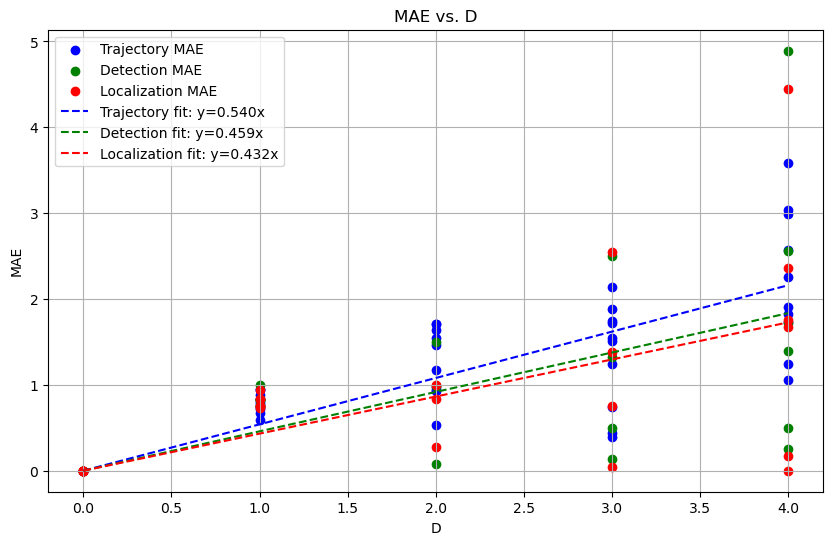

In [16]:
plot_MAEs_vs_D(D, MAE_t_array, MAE_d_array, MAE_l_array)

## 3. Full demo - 1000 frames

In [17]:
MAE_t_array_1000 = []
MAE_d_array_1000 = []
MAE_l_array_1000 = []

for d in D:
    MAE_t, MAE_d, MAE_l = compute_MAEs_setD(F[1], N, d)

    MAE_t_array_1000.append(MAE_t)
    MAE_d_array_1000.append(MAE_d)
    MAE_l_array_1000.append(MAE_l)

# convert to numpy arrays (2D)
MAE_t_array = np.array(MAE_t_array_1000)
MAE_d_array = np.array(MAE_d_array_1000)
MAE_l_array = np.array(MAE_l_array_1000)

Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
Frame 10
Frame 11
Frame 12
Frame 13
Frame 14
Frame 15
Frame 16
Frame 17
Frame 18
Frame 19
Frame 20
Frame 21
Frame 22
Frame 23
Frame 24
Frame 25
Frame 26
Frame 27
Frame 28
Frame 29
Frame 30
Frame 31
Frame 32
Frame 33
Frame 34
Frame 35
Frame 36
Frame 37
Frame 38
Frame 39
Frame 40
Frame 41
Frame 42
Frame 43
Frame 44
Frame 45
Frame 46
Frame 47
Frame 48
Frame 49
Frame 50
Frame 51
Frame 52
Frame 53
Frame 54
Frame 55
Frame 56
Frame 57
Frame 58
Frame 59
Frame 60
Frame 61
Frame 62
Frame 63
Frame 64
Frame 65
Frame 66
Frame 67
Frame 68
Frame 69
Frame 70
Frame 71
Frame 72
Frame 73
Frame 74
Frame 75
Frame 76
Frame 77
Frame 78
Frame 79
Frame 80
Frame 81
Frame 82
Frame 83
Frame 84
Frame 85
Frame 86
Frame 87
Frame 88
Frame 89
Frame 90
Frame 91
Frame 92
Frame 93
Frame 94
Frame 95
Frame 96
Frame 97
Frame 98
Frame 99
Frame 100
Frame 101
Frame 102
Frame 103
Frame 104
Frame 105
Frame 106
Frame 107
Frame 108
Frame 109
Frame 110


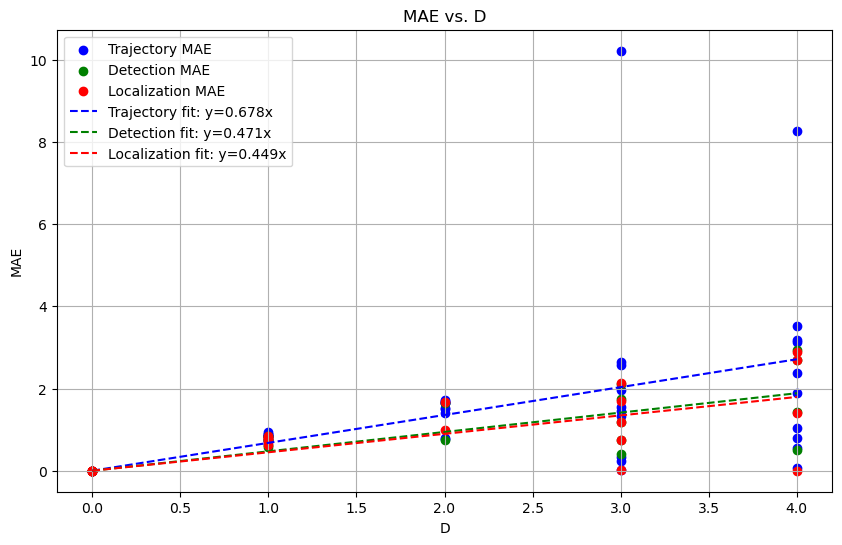

In [18]:
plot_MAEs_vs_D(D, MAE_t_array, MAE_d_array, MAE_l_array)

outliers trajectory:  
- sortie image
- 

## Cleaner version: D vs. D_GT

### 10 frames

In [ ]:
D_t_10 = []
D_d_10 = []
D_l_10 = []

for d in D:
    D_t, D_d, D_l = compute_Ds_setD(F[0], N, d)
    D_t_10.append(D_t)
    D_d_10.append(D_d)
    D_l_10.append(D_l)

Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[-0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000]
D_detection:
['-0.000', '-0.000', '-0.000', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', '-0.000', '-0.000']
D_localization:
['-0.000', '-0.000', '-0.000', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', '-0.000', '-0.000']
Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[0.302, 0.151, 0.101, 0.083, 0.692, 0.150, 0.465, 0.078, 0.388, 0.154]
D_detection:
['nan', 'nan', '0.050', '0.153', '0.590', 'nan', '0.393', '0.094', '0.384', '0.170']
D_localization:
['nan', 'nan', '0.089', '0.167', '0.552', 'nan', '0.293', '0.105', '0.437', '0.205']
Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[0.118, 0.898, 0.385, 0.985, 1.369, 0.415, 0.459, 0.366, 1.730, 0.438]
D_detection:
['0.112', '0.397', '0.500', 'nan', 'nan', '0.650', '2.6

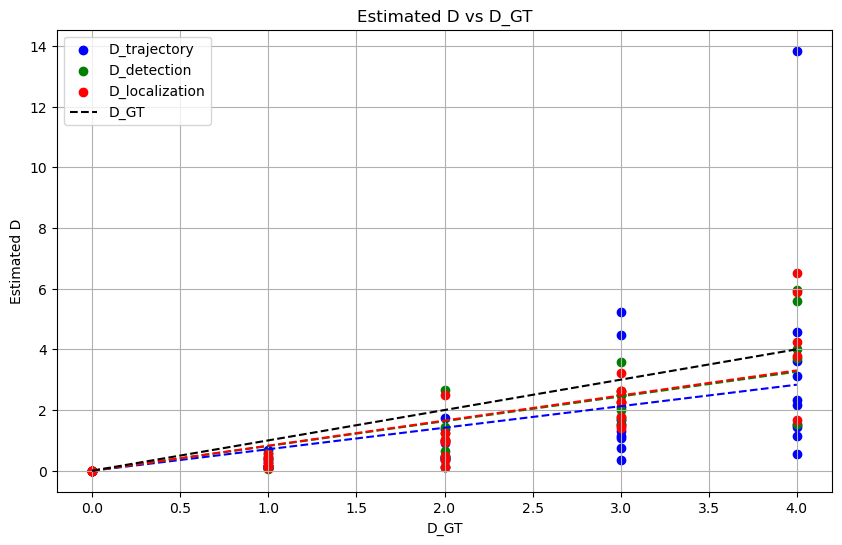

In [39]:
plot_Ds_vs_D_GT(D_t_10, D_d_10, D_l_10, D)

### 1000 frames

Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[-0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000]
D_detection:
['-0.000', '-0.000', '-0.000', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', 'nan', '-0.000']
D_localization:
['-0.000', '-0.000', '-0.000', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', 'nan', '-0.000']
Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[0.283, 0.461, 0.395, 0.265, 0.283, 0.297, 0.233, 0.098, 0.103, 0.385]
D_detection:
['0.286', '0.407', '0.279', 'nan', '0.393', 'nan', '0.107', '0.250', 'nan', '0.252']
D_localization:
['0.261', '0.417', '0.319', 'nan', '0.318', 'nan', '0.134', '0.225', 'nan', '0.210']
Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[2.290, 0.233, 0.430, 1.800, 0.639, 0.643, 0.660, 1.179, 0.376, 0.350]
D_detection:
['nan', 'nan', '1.574', '0.298', '0.522', '0.645', 'nan', 'na

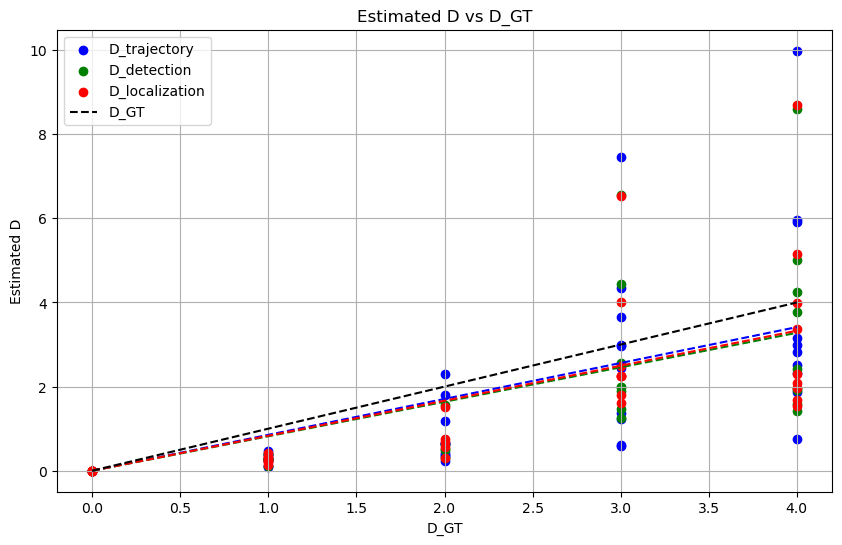

In [41]:
D_t_1000 = []
D_d_1000 = []
D_l_1000 = []

for d in D:
    D_t, D_d, D_l = compute_Ds_setD(F[0], N, d)
    D_t_1000.append(D_t)
    D_d_1000.append(D_d)
    D_l_1000.append(D_l)

plot_Ds_vs_D_GT(D_t_1000, D_d_1000, D_l_1000, D)

## Full demo extended - 1000 frames, 10 repetitions

Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[-0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000, -0.000]
D_detection:
['nan', '-0.000', '-0.000', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', '-0.000', 'nan']
D_localization:
['nan', '-0.000', '-0.000', '-0.000', '-0.000', 'nan', '-0.000', '-0.000', '-0.000', 'nan']
Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[0.051, 0.097, 0.098, 0.580, 0.143, 0.067, 0.251, 0.403, 0.245, 0.106]
D_detection:
['0.044', 'nan', '0.304', '0.393', 'nan', 'nan', 'nan', '0.116', '0.317', '0.575']
D_localization:
['0.029', 'nan', '0.347', '0.312', 'nan', 'nan', 'nan', '0.109', '0.234', '0.421']
Frame 0
Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
D_trajectory: 
[1.211, 0.472, 0.970, 0.314, 1.294, 1.087, 0.524, 1.197, 3.158, 1.293]
D_detection:
['nan', 'nan', 'nan', '0.244', '1.546', 'nan', '1.250', '0.898', '2.831

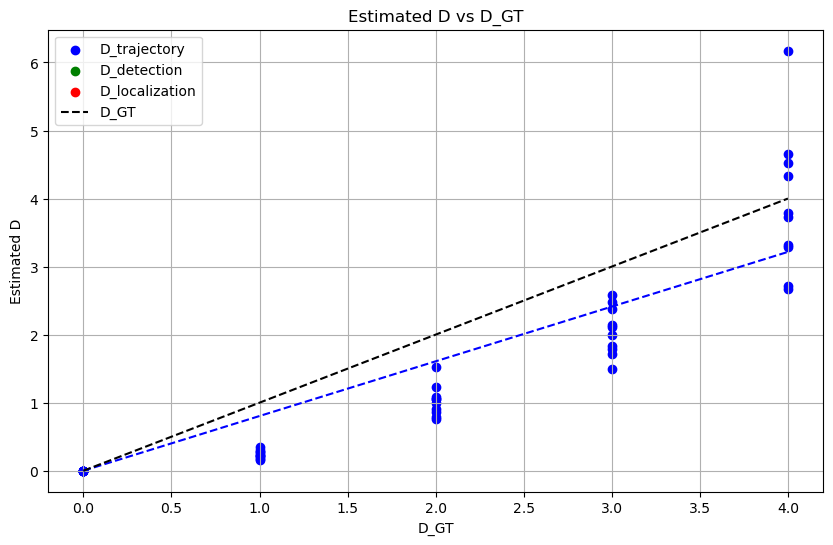

In [42]:
# same experiment, done 10 times, average D values for each D_GT and method
N_repeats = 10

D_t_avg = []
D_d_avg = []
D_l_avg = []

for i in range(N_repeats):
    D_t_1000 = []
    D_d_1000 = []
    D_l_1000 = []
    
    for d in D:
        D_t, D_d, D_l = compute_Ds_setD(F[0], N, d)
        D_t_1000.append(D_t)
        D_d_1000.append(D_d)
        D_l_1000.append(D_l)

    D_t_avg.append(D_t_1000)
    D_d_avg.append(D_d_1000)
    D_l_avg.append(D_l_1000)

# convert to numpy arrays for easier averaging
D_t_avg = np.array(D_t_avg)
D_d_avg = np.array(D_d_avg)
D_l_avg = np.array(D_l_avg)

D_t_mean = np.mean(D_t_avg, axis=0)
D_d_mean = np.mean(D_d_avg, axis=0)
D_l_mean = np.mean(D_l_avg, axis=0)

plot_Ds_vs_D_GT(D_t_mean, D_d_mean, D_l_mean, D)


-> too many nans in estimated D_d and D_l.